## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 08 · The dwelling tier: the calibrated model on individual dwellings

The archetype tier scales representative intensities to every dwelling; the dwelling tier simulates each
dwelling with its own geometry and its own household draw. This notebook runs the calibrated model on a
stratified sample of the stock (`STOCK_MODE = "sample"`, about 25 min on 32 cores) or on every dwelling
(`"full"`, about 6 h, checkpointed and resumable) and checks the archetype-tier scaling against it: the
compression error is large for individual dwellings and must cancel in area totals for the LSOA and ward
results of the later notebooks to hold.

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.schedules import sample_household, dwelling_schedule
from ukubem.systems import delivered_energy, SYSTEM_DEFAULTS
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_BOUNDS, POST_FIXED, make_representatives,
                              _stock_delivered, fit_post_params, objective_from_stock)
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
STOCK_MODE = "sample"            # "sample" | "full"
N_SAMPLE = 1200
theta = json.load(open(UBEM_OUT / "06_calibrated_theta.json"))
phys, post = theta["physics"], theta["post"]
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
A_cal = UKGeometryAssumptions().with_(wall_u_scale=phys["wall_u_scale"], roof_u_scale=phys["roof_u_scale"], window_u_scale=phys["window_u_scale"],
                                      infil_scale=phys["infil_scale"], gains_scale=phys["gains_scale"], setpoint_offset_c=phys["setpoint_offset_c"],
                                      stochastic_setback_c=phys.get("setback_c", 12.0))
print("calibrated physics:", {k: round(v, 3) for k, v in phys.items()}); print("post:", {k: round(v, 3) for k, v in post.items()})

calibrated physics: {'wall_u_scale': 1.065, 'roof_u_scale': 1.125, 'window_u_scale': 1.25, 'infil_scale': 0.813, 'gains_scale': 0.816, 'setpoint_offset_c': 1.0, 'setback_c': 15.691}
post: {'weather_scale': 1.0, 'boiler_eff': 0.82, 'hp_scop': 2.8, 'dhw_hp_scop': 2.0, 'dhw_scale': 1.0}


## 1 · Dwelling-level run

In [3]:
if STOCK_MODE == "sample":
    sel = inputs.groupby("construction_sa", group_keys=False).apply(lambda g: g.sample(max(3, int(round(N_SAMPLE * len(g) / len(inputs)))), random_state=SEED))
else:
    sel = inputs
ckpt = UBEM_OUT / f"08_stock_{STOCK_MODE}.parquet"
t0 = time.time()
res = simulate_stock(sel, str(EPW), str(PBE_SRC), A_cal, checkpoint=ckpt, n_jobs=N_JOBS, chunk_size=20, stochastic=True, seed=SEED,
                     post=post, resume=True, verbose=0)
res = res.set_index("dwelling_id").join(inputs[["construction_sa", "size_class", "LSOA", "ward", "accommodation_type", "age_band_resolved"]])
print(f"{len(res):,} dwellings simulated ({(res.status == 'ok').mean():.1%} ok) in {(time.time()-t0)/60:.1f} min")
res.to_parquet(UBEM_OUT / f"08_stock_{STOCK_MODE}_joined.parquet")
res[["Q_H_kWh_m2", "T_op_heating_season_C", "delivered_gas_kWh", "delivered_elec_kWh", "dhw_kWh", "appliances_kWh"]].describe().round(1)

1,201 dwellings simulated (100.0% ok) in 0.0 min


,Q_H_kWh_m2,T_op_heating_season_C,delivered_gas_kWh,delivered_elec_kWh,dhw_kWh,appliances_kWh
count,1201.0,1201.0,1201.0,1201.0,1201.0,1201.0
mean,89.2,19.3,12366.6,4363.2,1461.0,3303.0
std,63.1,2.2,11873.2,2970.1,148.6,1131.4
min,0.0,14.3,0.0,1160.4,1077.5,967.3
25%,43.3,17.8,4232.1,3174.4,1366.5,2550.6
50%,77.2,18.8,9779.5,3861.8,1497.7,3175.4
75%,124.2,20.4,16934.0,4665.9,1581.7,3912.5
max,396.9,27.5,92210.0,53244.4,1823.0,8979.5


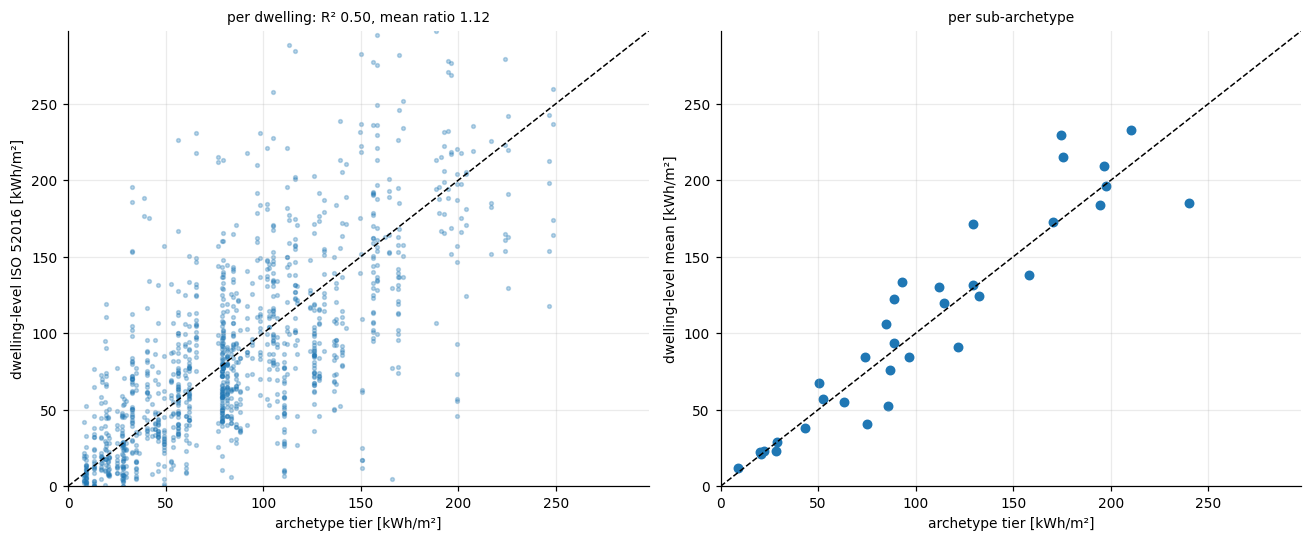

In [4]:
# does the archetype-tier scaling reproduce the dwelling-level run?
inten_cal = pd.read_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv", index_col=0)
tier = res.join(inten_cal.set_index(["construction_sa", "size_class"])["Q_H_kWh_m2"].rename("tier_kWh_m2"), on=["construction_sa", "size_class"])
tier["tier_kWh_m2"] *= post["weather_scale"]
ok = tier[tier.status == "ok"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(ok["tier_kWh_m2"], ok["Q_H_kWh_m2"], s=6, alpha=0.3); lim = [0, ok[["tier_kWh_m2", "Q_H_kWh_m2"]].quantile(0.995).max()]
axes[0].plot(lim, lim, "k--", lw=1); axes[0].set_xlim(lim); axes[0].set_ylim(lim); axes[0].set_xlabel("archetype tier [kWh/m²]"); axes[0].set_ylabel("dwelling-level ISO 52016 [kWh/m²]")
r2 = np.corrcoef(ok["tier_kWh_m2"], ok["Q_H_kWh_m2"])[0, 1] ** 2
axes[0].set_title(f"per dwelling: R² {r2:.2f}, mean ratio {(ok['Q_H_kWh_m2'] / ok['tier_kWh_m2']).mean():.2f}", fontsize=9)
g = ok.groupby("construction_sa")[["Q_H_kWh_m2", "tier_kWh_m2"]].mean()
axes[1].scatter(g["tier_kWh_m2"], g["Q_H_kWh_m2"], s=30); axes[1].plot(lim, lim, "k--", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("archetype tier [kWh/m²]"); axes[1].set_ylabel("dwelling-level mean [kWh/m²]"); axes[1].set_title("per sub-archetype", fontsize=9)
plt.tight_layout(); fig.savefig(FIG_UBEM / f"08_tier_vs_dwelling_{STOCK_MODE}.png", bbox_inches="tight"); plt.show()

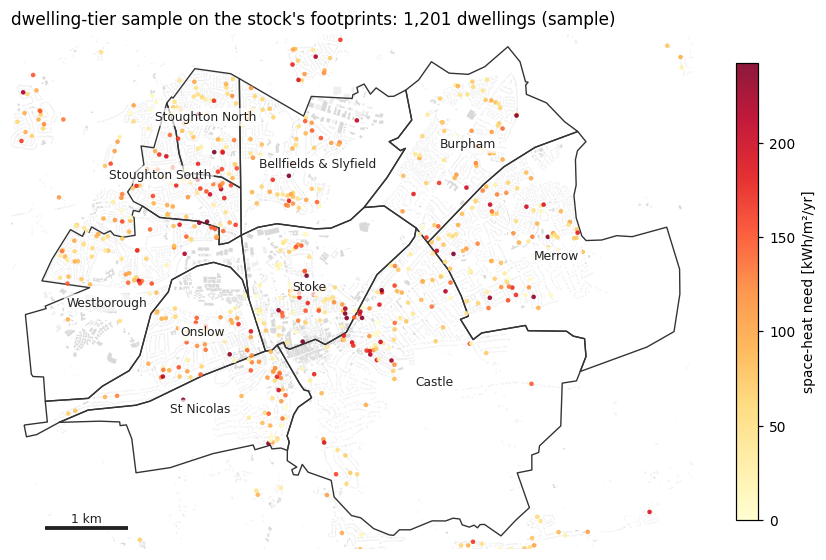

,n,kWh_m2,gas_kWh,elec_kWh,T_op_winter
ward,,,,,
Bellfields & Slyfield,55,92.0,12217.0,3802.0,19.0
Burpham,51,86.0,13845.0,4768.0,20.0
Castle,82,98.0,15499.0,4780.0,19.0
Merrow,85,87.0,14503.0,4253.0,20.0
Onslow,53,95.0,14320.0,4566.0,19.0
St Nicolas,39,94.0,12632.0,4630.0,20.0
Stoke,79,76.0,6512.0,4482.0,20.0
Stoughton North,47,81.0,10160.0,3947.0,20.0
Stoughton South,45,118.0,16188.0,4312.0,19.0


In [5]:
# where the heat goes: intensity map and ward table
from ukubem import maps
import config as CFG
ok = res[res.status == "ok"].join(labels[["lon", "lat"]])
L = maps.load_layers(CFG, town_only=False)
fig, ax = plt.subplots(figsize=(10, 9)); maps.base_map(ax, L)
pts = maps.points_27700(ok[["lon", "lat"]])
sc = ax.scatter(pts.geometry.x, pts.geometry.y, c=ok["Q_H_kWh_m2"].clip(upper=ok["Q_H_kWh_m2"].quantile(0.98)), s=9, cmap="YlOrRd", alpha=0.9, zorder=6, linewidths=0)
plt.colorbar(sc, ax=ax, label="space-heat need [kWh/m²/yr]", shrink=0.6)
maps.finish(ax, L, title=f"dwelling-tier sample on the stock's footprints: {len(ok):,} dwellings ({STOCK_MODE})")
fig.savefig(FIG_UBEM / f"08_map_{STOCK_MODE}.png", bbox_inches="tight"); plt.show()
ward = ok.dropna(subset=["ward"]).groupby("ward").agg(n=("Q_H_kWh", "size"), kWh_m2=("Q_H_kWh_m2", "mean"), gas_kWh=("delivered_gas_kWh", "mean"), elec_kWh=("delivered_elec_kWh", "mean"), T_op_winter=("T_op_heating_season_C", "mean")).round(0)
ward.to_csv(UBEM_OUT / f"08_ward_{STOCK_MODE}.csv"); ward

## What is in `outputs/ubem/`

* `06_calibrated_theta.json`, `06_calibration_history.csv`, `06_theta_comparison.csv` — the calibration;
* `06_stock_calibrated.parquet`, `06_lsoa_calibrated.csv` — calibrated baseline per dwelling and per LSOA;
* `08_stock_<mode>_joined.parquet`, `08_ward_<mode>.csv` — dwelling-level ISO 52016 results (needs, temperatures, fuels);
* figures `08_tier_vs_dwelling_<mode>.png`, `08_map_<mode>.png`.